# Decision tree and random forest classifier Assignment

## Business Understanding

The objective of this assignment is to build decision tree and random forest classifiers to identify phishing websites based on various features extracted from the websites. The dataset used to accomplish this task is the Phishing Websites dataset from the UCI Machine Learning Repository.

The models will be evaluated based on their accuracy and confusion matrices to verify their performance in classifying websites correctly. Since the idea of the models is that they could be used to automatically flag potentially phishing websites, it is crucial that they minimize both false negatives (phishing websites classified as safe) and false positives (safe websites classified as phishing). False negatives could lead to users falling victim to phishing attacks, while false positives could lead to unnecessary blocking of legitimate websites.

## Data Understanding

The data used in this assignment is the Phishing Websites dataset from the UCI Machine Learning Repository. The dataset contains 11,055 datapoints, each representing a website. Each datapoint has 31 features that describe various characteristics of their websites, such as URL length, presence of certain keywords, and other attributes that may indicate whether a website is phishing(-1), suspicious(0) or safe(1).

Below you can find the full table of features in the dataset:

|           Syntax            |                                         Description                                          |                             Value                             |
|:---------------------------:|:--------------------------------------------------------------------------------------------:|:-------------------------------------------------------------:|
|      having_IP_Address      |                            Whether the URL contains an IP address                            |                -1 if it does, 1 if it does not                |
|         URL_Length          |                     Whether the length of the URL exceeds certain values                     | -1 if more than 75, 0 if between 54 and 75, 1 if less than 54 |
|     Shortening_Service      |                           Whether a URL shortening service is used                           |                  -1 if it is, 1 if it is not                  |
|      having_At_Symbol       |                             Whether the URL contains '@' symbol                              |                -1 if it does, 1 if it does not                |
|  double_slash_redirecting   |                       Whether the URL contains '//' after the protocol                       |                -1 if it does, 1 if it does not                |
|        Prefix_Suffix        |                             Whether the URL contains '-' symbol                              |                -1 if it does, 1 if it does not                |
|      having_Sub_Domain      |                               Whether the URL has a subdomain                                |                -1 if it does, 1 if it does not                |
|       SSLfinal_State        |                             Whether the SSL certificate is valid                             |                  -1 if it is not, 1 if it is                  |
| Domain_registeration_length |                 Whether the domain registration expires in less than 1 year                  |                -1 if it does, 1 if it does not                |
|           Favicon           |                         Whether the favicon is from the same domain                          |                  -1 if it is not, 1 if it is                  |
|            port             |                             Whether a non-standard port is used                              |                  -1 if it is, 1 if it is not                  |
|         HTTPS_token         |                         Whether 'HTTPS' token is present in the URL                          |                  -1 if it is, 1 if it is not                  |
|         Request_URL         | Whether more than 61% of external objects (images/videos) are loaded from a different domain |                    -1 if true, 1 if false                     |
|        URL_of_Anchor        |  Whether more than 67% of the hyperlink tags point to external domains or use "dummy" links  |                -1 if it does, 1 if it does not                |
|        Links_in_tags        |               Whether 81% of links in meta, script, and link tags are external               |               -1 if they are, 1 if they are not               |
|             SFH             |   Server Form Handler: If the form "action" is empty, "about:blank", or a different domain   |                  -1 if it is, 1 if it is not                  |
|     Submitting_to_email     |            Whether the form uses mailto: or the mail() function to send user data            |                -1 if it does, 1 if it does not                |
|        Abnormal_URL         |                         Whether the hostname is missing from the URL                         |                  -1 if it is, 1 if it is not                  |
|          Redirect           |                           Does the site have more than 4 redirects                           |                -1 if it does, 1 if it does not                |
|        on_mouseover         |      Whether JavaScript is used to change the status bar on hover to hide the real link      |                  -1 if it is, 1 if it is not                  |
|         RightClick          |                 Whether the right-click function is disabled via JavaScript                  |                  -1 if it is, 1 if it is not                  |
|         popUpWindow         |          Whether pop-up windows are used to ask users to enter personal information          |               -1 if they are, 1 if they are not               |
|           Iframe            |                                   Whether iframes are used                                   |               -1 if they are, 1 if they are not               |
|        age_of_domain        |                          Whether the domain is older than 6 months                           |                  -1 if it is not, 1 if it is                  |
|          DNSRecord          |                                 Whether a DNS record exists                                  |                -1 if it does not, 1 if it does                |
|         web_traffic         |            Whether the website has Alexa rank less than 150,000 or has no traffic            |                -1 if it does, 1 if it does not                |
|          Page_Rank          |                         Whether the Google PageRank is less than 0.2                         |                  -1 if it is, 1 if it is not                  |
|        Google_Index         |                           Whether the website is indexed by Google                           |                  -1 if it is not, 1 if it is                  |
|   Links_pointing_to_page    |                            Is there any link pointing to the page                            |             -1 if there are 0, 1 if there are any             |
|     Statistical_report      |                         Whether the website is listed in blacklists                          |                  -1 if it is, 1 if it is not                  |
|           result            |                                  The classification result                                   |                  -1 for phishing, 1 for safe                  |


In [152]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# data to dataframe
X = phishing_websites.data.original

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_in_tags    

## Data Preparation

The dataset is clean and does not contain any missing values, so no cleaning is necessary.

The preparation then only involves separating the features from the target variable, which in this case is whether the website is phishing or safe. Finally, the ID column is dropped as it does not provide any useful data for the classification.

Since the features are already on the same scale, there is no need for scaling.

The prepared data is then split into training and testing sets. The training set will be used to train the decision tree and random forest classifiers, while the testing set will be used to evaluate their accuracy. In this case, 30% of the data was used for testing.

In [142]:
from sklearn.model_selection import train_test_split

y = X['result']
X = X.drop(columns=['result'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)

## Modeling

With the data prepared and split, it can now be used to train both the decision tree and random forest classifiers.

### Decision Tree Classifier

The decision tree classifier was trained using the training data, and its accuracy was evaluated on both the training and testing data. Several hyperparameters for the maximum depth of the tree were used to train different models, and the accuracies of each model were evaluated. Each accuracy value for both tests were stored in lists and later plotted to visualize how the accuracy changes with different maximum depth values. The difference between the training and testing accuracies was also calculated to evaluate the potential overfitting of the models. Finally, the decision tree with the maximum depth of 3 was chosen for the final model, as it provided a good balance between accuracy and overfitting as well as being easy to visualize and interpret.

Since maximum depth of 10 scored higher accuracy without veering off of the training accuracy (difference 0.011 %), it could also be considered as the best model. Ultimately, the choice of the best model depends on the specific requirements of the task at hand and in this case the decision tree with a maximum depth of 3 was chosen for its interpretability and relatively good performance.

Accuracies on test data with n depth:
[(1, 0.885), (2, 0.905), (3, 0.907), (4, 0.919), (5, 0.923), (6, 0.931), (7, 0.934), (8, 0.937), (9, 0.94), (10, 0.949), (11, 0.953), (12, 0.951), (13, 0.951), (14, 0.957), (15, 0.956), (16, 0.958), (17, 0.958), (18, 0.96), (19, 0.959), (20, 0.96), (21, 0.959), (22, 0.96), (23, 0.957), (24, 0.956)]

Accuracies on training data with n depth:
[(1, 0.891), (2, 0.907), (3, 0.908), (4, 0.921), (5, 0.923), (6, 0.934), (7, 0.937), (8, 0.942), (9, 0.95), (10, 0.96), (11, 0.969), (12, 0.975), (13, 0.978), (14, 0.982), (15, 0.984), (16, 0.986), (17, 0.988), (18, 0.99), (19, 0.991), (20, 0.991), (21, 0.991), (22, 0.991), (23, 0.991), (24, 0.991)]

Differences between training and test accuracies with n depth:
[(1, 0.006), (2, 0.002), (3, 0.001), (4, 0.002), (5, 0.0), (6, 0.003), (7, 0.003), (8, 0.005), (9, 0.01), (10, 0.011), (11, 0.016), (12, 0.024), (13, 0.027), (14, 0.025), (15, 0.028), (16, 0.028), (17, 0.03), (18, 0.03), (19, 0.032), (20, 0.031), (21, 0.

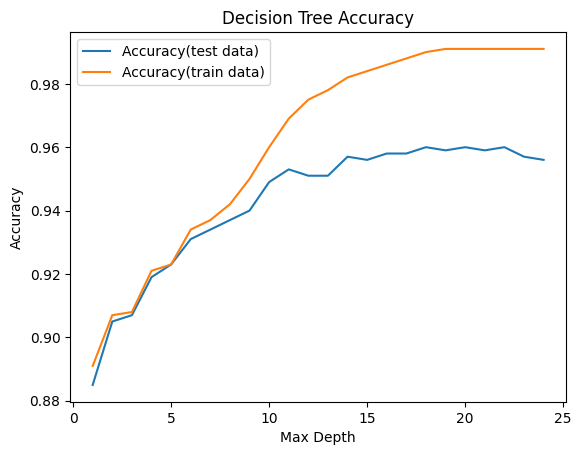

In [143]:
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier

accuracy = []
accuracy_train = []

depth = range(1, 25)

for d in depth:
    model = DecisionTreeClassifier(max_depth=d, random_state=67)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)

    accuracy.append(round(acc, 3))
    accuracy_train.append(round(train_acc, 3))

accuracy_diff = [round(train - test, 3) for train, test in zip(accuracy_train, accuracy)]

print(f"Accuracies on test data with n depth:\n{list(zip(depth, accuracy))}")
print()
print(f"Accuracies on training data with n depth:\n{list(zip(depth, accuracy_train))}")
print()
print(f"Differences between training and test accuracies with n depth:\n{list(zip(depth,accuracy_diff))}")


plt.plot(depth, accuracy, label='Accuracy(test data)')
plt.plot(depth, accuracy_train, label='Accuracy(train data)')
plt.ylabel('Accuracy')
plt.xlabel('Max Depth')
plt.title('Decision Tree Accuracy')
plt.legend()
plt.show()

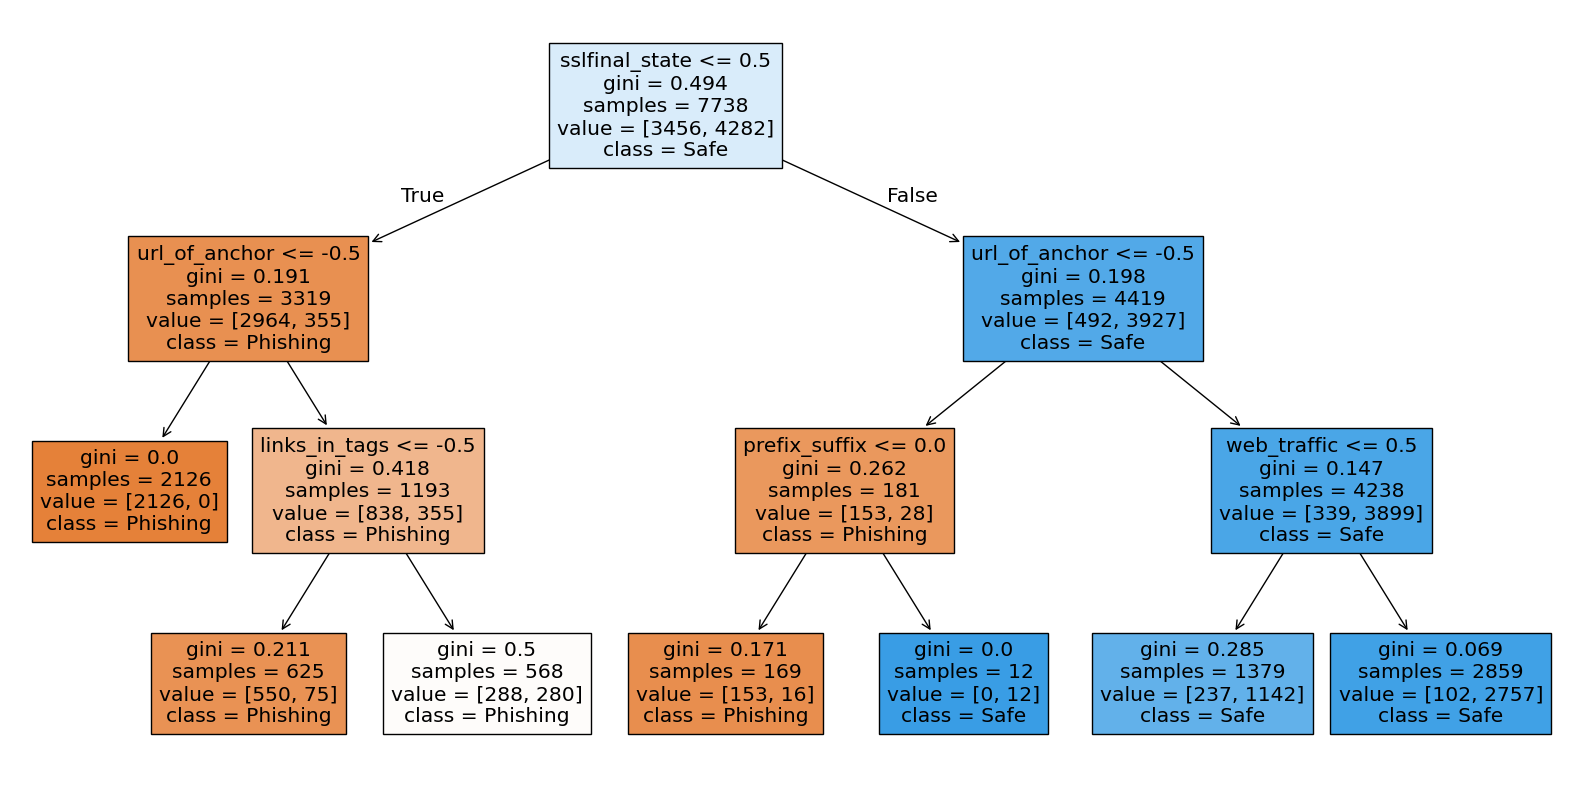

In [155]:
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(max_depth=3, random_state=67)
model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(model, filled=True,
                 feature_names=X.columns,
                 class_names=['Phishing', 'Safe'])
plt.show()

Above is the visualization of the final decision tree model with a maximum depth of 3. As can be seen, the tree uses only a few features to make its classifications. It also does not branch out too much making it more readable.

Below are the written instructions for deciding whether a website is phishing or safe based on the decision tree:

1. Check the site has a valid SSL certificate (SSLfinal_State).
   - If not valid, classify as Phishing.
   - If valid, proceed to the next step.


2. Check if the site contains more than 67% of external or dummy links in its tags.
   - If yes, proceed to the next step.
   - If no, classify as Safe.


3. Check if the URL contains a prefix or suffix.
   - If yes, classify as Phishing.
   - If no, classify as Safe.

With these instructions, one can manually classify websites as phishing or not with relatively high accuracy.

### Random Forest Classifier

The random forest classifier was trained using the same training data as the decision tree classifier. Several hyperparameters for the number of trees, maximum samples, and maximum features were used to train different models, and the accuracy of each model was evaluated. 216 different combinations of hyperparameters were tested using nested loops to find the best combination. The combination that yielded the highest accuracy was selected for the final evaluation. The total time taken for the hyperparameter tuning process was 1 hour and 19 minutes.

In [145]:
import datetime
from sklearn.ensemble import RandomForestClassifier

n_trees = [25, 50, 100, 150, 200, 250]
max_samples = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
max_features = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

best_hyperparams = None
highest_accuracy = 0
start_time = datetime.datetime.now()

for n in n_trees:
    for ms in max_samples:
        for mf in max_features:
            model = RandomForestClassifier(n_estimators=n,
                                           max_samples=ms,
                                           max_features=mf,
                                           random_state=67)

            model.fit(X_train, y_train)
            accuracy = model.score(X_test, y_test)

            if accuracy > highest_accuracy:
                highest_accuracy = accuracy
                best_hyperparams = (n, ms, mf)

end_time = datetime.datetime.now()
elapsed_time = end_time - start_time
print(f"Hyperparameter tuning took: {str(elapsed_time).split('.')[0]}")
print(f"Best hyperparameters found: n_estimators={best_hyperparams[0]}, max_samples={best_hyperparams[1]}, max_features={best_hyperparams[2]}")
print(f"Highest accuracy achieved: {highest_accuracy:.4f}")

Hyperparameter tuning took: 1:19:32
Best hyperparameters found: n_estimators=25, max_samples=0.8, max_features=0.9
Highest accuracy achieved: 0.9680


## Evaluation

Both the decision tree and random forest classifiers were evaluated using confusion matrices and classification reports to visualize their performance in classifying websites correctly.

### Decision Tree Classifier Evaluation

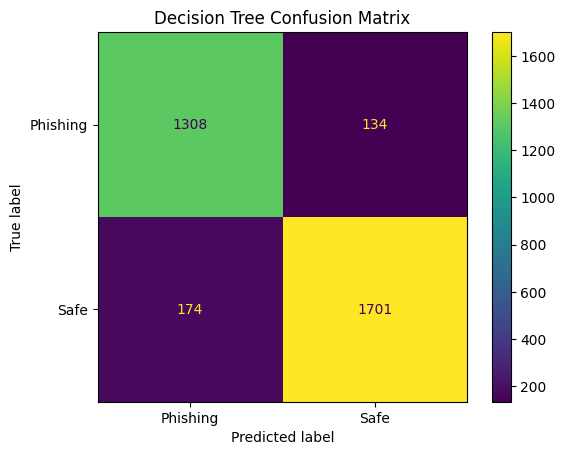

              precision    recall  f1-score   support

    Phishing       0.88      0.91      0.89      1442
        Safe       0.93      0.91      0.92      1875

    accuracy                           0.91      3317
   macro avg       0.90      0.91      0.91      3317
weighted avg       0.91      0.91      0.91      3317



In [160]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

tree_model = DecisionTreeClassifier(max_depth=3, random_state=67)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Safe'])
cmd.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

tree_report = classification_report(y_test, y_pred, target_names=['Phishing', 'Safe'])
print(tree_report)

As can be seen from the confusion matrix and classification report, the decision tree classifier chosen for the final model, whilst being extremely simple, performs quite well with an accuracy of approximately 91 % and its precision and recall values being 0.88 and 0.91 respectively for the phishing class. The safe class has precision of 0.93 and recall of 0.91. Overall, the decision tree classifier demonstrates that with relatively simple rules, it is possible to achieve good performance in classifying phishing websites.

### Random Forest Classifier Evaluation

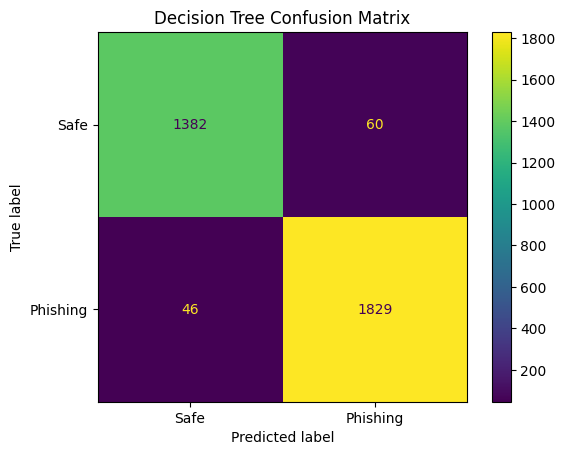

              precision    recall  f1-score   support

        Safe       0.97      0.96      0.96      1442
    Phishing       0.97      0.98      0.97      1875

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317



In [159]:
forest_model = RandomForestClassifier(n_estimators=25,
                               max_samples=0.8,
                               max_features=0.9,
                               random_state=67)
forest_model.fit(X_train, y_train)

y_pred = forest_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Safe'])
cmd.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

forest_report = classification_report(y_test, y_pred, target_names=['Phishing', 'Safe'])
print(forest_report)

As can be seen from the confusion matrix and classification report, the random forest classifier outperforms the decision tree classifier with an accuracy of approximately 97 %. The precision and recall values for the phishing class are 0.94 and 0.96 respectively, while for the safe class they are 0.96 and 0.94 respectively. Overall, the random forest classifier demonstrates how using an ensemble of decision trees can improve performance in classifying phishing websites whilst sacrificing most of the interpretability.

## Deployment

If deployed, these models could be used to automatically flag potentially phishing websites based on automated feature extraction. For this the random forest classifier would be the superior choice due to its higher accuracy, precision and recall values. However, if written instructions for manual classification are needed, the decision tree classifier would be more suitable since the random forest classifier is really human interpretable.